In [ ]:
# !pip install torch torchvision transformers pillow spacy
# !python -m spacy download en_core_web_sm

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
   ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
    --------------------------------------- 0.3/15.3 MB ? eta -:--:--
    --------------------------------------- 0.3/15.3 MB ? eta -:--:--
    --------------------------------------- 0.3/15.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.3 MB 441.3 kB/s eta 0:00:34
   - -------------------------------------- 0.5/15.3 MB 441.3 kB/s eta 0:00:34
   - -------------------------------------- 0.5/15.3 MB 441.3 kB/s eta 0:00:34
   - -------------------------------------- 0.5/15.3 MB 441.3 kB/s eta 0:00:34
   -- ------------------------------------- 0.8/15.3 MB 390.1 k

Import library

In [2]:
import os
import torch
import spacy

from PIL import Image
from IPython.display import display

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    CLIPProcessor,
    CLIPModel
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device yang digunakan:", device)

Device yang digunakan: cpu


Load BLIP

In [3]:
print("Loading BLIP...")

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("BLIP berhasil dimuat.")

Loading BLIP...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

c:\Users\elsae\miniconda3\envs\tugasakhir\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\elsae\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP berhasil dimuat.


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Load CLIP

In [4]:
print("Loading CLIP...")
clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)
print("CLIP berhasil dimuat.")

Loading CLIP...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

c:\Users\elsae\miniconda3\envs\tugasakhir\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\elsae\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP berhasil dimuat.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Load spaCy

In [5]:
nlp = spacy.load("en_core_web_sm")
print("spaCy berhasil dimuat.")

spaCy berhasil dimuat.


Function BLIP Caption

In [6]:
def generate_caption(image):
    inputs = blip_processor(
        images=image,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        output = blip_model.generate(
            **inputs,
            max_new_tokens=50
        )
    caption = blip_processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

Mengambil kandidat dari caption

In [7]:
def extract_candidates(caption):
    doc = nlp(caption)
    candidates = []
    for chunk in doc.noun_chunks:

        candidate = chunk.text.lower().strip()
        # Hapus artikel bahasa Inggris
        articles = [
            "a ",
            "an ",
            "the "
        ]
        for article in articles:

            if candidate.startswith(article):

                candidate = candidate[len(article):]
        # Hindari kandidat kosong / duplikat
        if (
            candidate
            and candidate not in candidates
            and len(candidate) > 2
        ):
            candidates.append(candidate)

    return candidates

CLIP ranking

In [8]:
def rank_candidates(image, candidates):

    if len(candidates) == 0:
        return []
    # Buat prompt agar lebih natural untuk CLIP
    prompts = [
        f"a photo of {candidate}"
        for candidate in candidates
    ]

    inputs = clip_processor(
        text=prompts,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits = outputs.logits_per_image
        probabilities = logits.softmax(dim=1)[0]

    results = []

    for candidate, probability in zip(
        candidates,
        probabilities
    ):
        results.append({
            "scene": candidate,
            "score": probability.item()
        })
    # Ranking dari terbesar
    results = sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

    return results

Input gambar

In [18]:
filename = input(
    "Masukkan nama file gambar: "
).strip()
image_path = os.path.join(
    "image",
    filename
)
print("Path gambar:", image_path)

Path gambar: image\image_000011.jpg


Buka & Tampilkan gambar

Gambar berhasil dibuka.


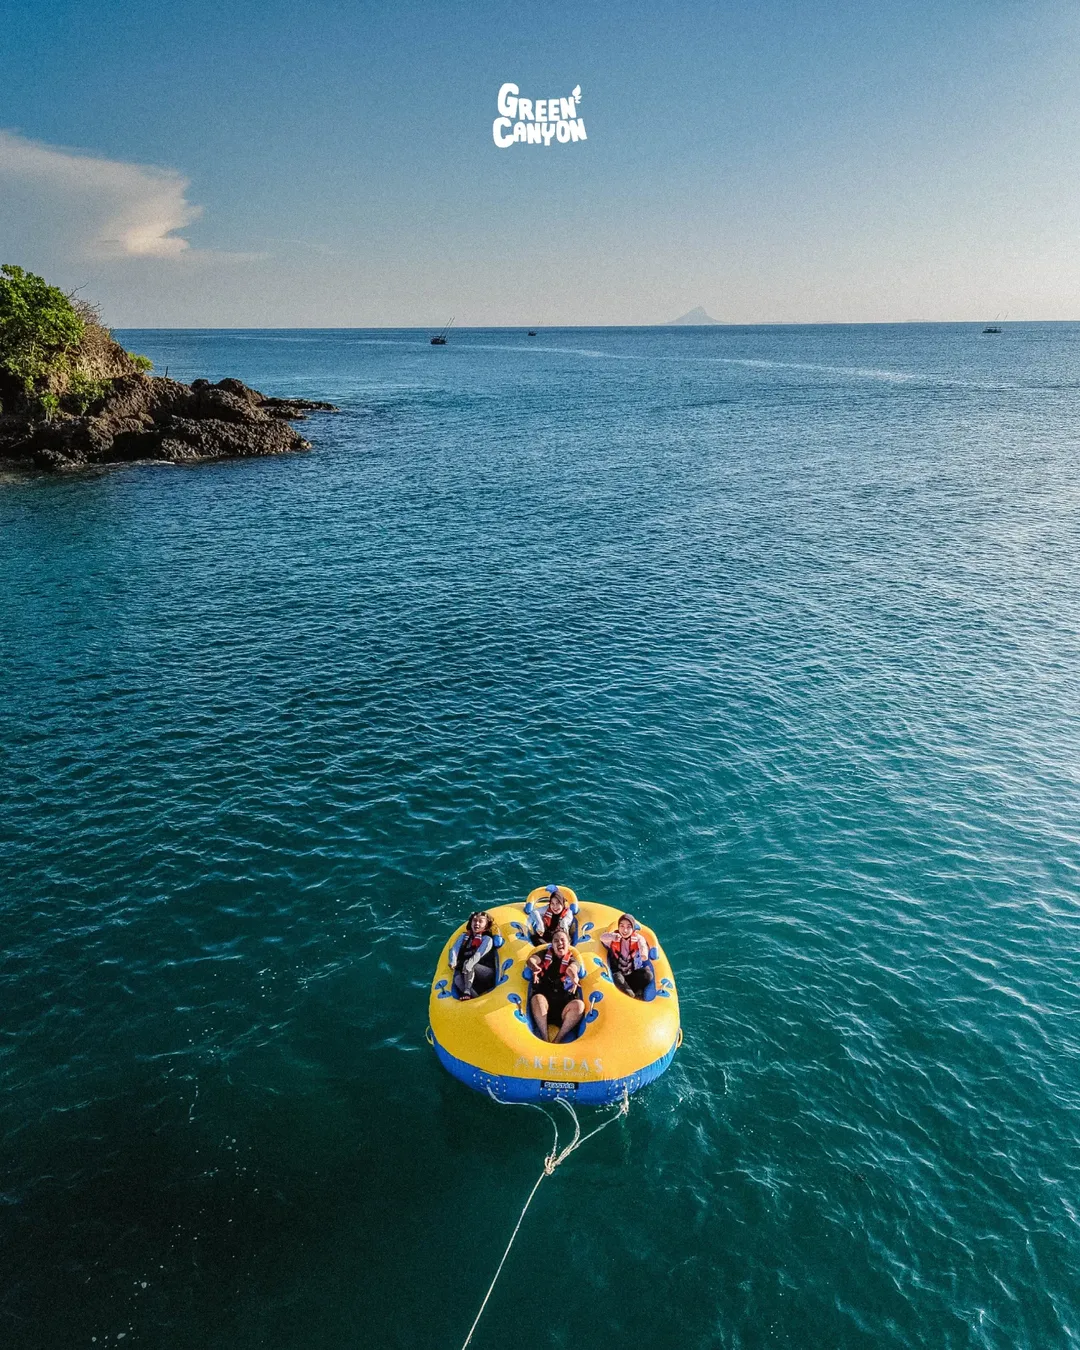

In [19]:
if os.path.exists(image_path):
    image = Image.open(
        image_path
    ).convert("RGB")
    print("Gambar berhasil dibuka.")
    display(image)

else:
    print("Gambar tidak ditemukan!")
    print("Periksa nama file:", image_path)

Jalankan blip

In [20]:
caption = generate_caption(image)
print("Caption BLIP:")
print(caption)

Caption BLIP:
a man in a yellow raft floating on the water


Ambil kandidat

In [21]:
candidates = extract_candidates(
    caption
)

print("Kandidat scene:")
for candidate in candidates:

    print("-", candidate)

Kandidat scene:
- man
- yellow raft
- water


Jalankan CLIP

In [22]:
results = rank_candidates(
    image,
    candidates
)

print("Hasil CLIP:")
for result in results:

    print(
        result["scene"],
        round(result["score"], 4)
    )

Hasil CLIP:
yellow raft 0.9752
water 0.0241
man 0.0006


Top 3

In [23]:
top_3 = results[:3]
print("         TOP 3 SCENE")

for i, result in enumerate(
    top_3,
    start=1
):

    print(
        f"{i}. {result['scene']} "
        f"- Score: {result['score']:.4f}"
    )

         TOP 3 SCENE
1. yellow raft - Score: 0.9752
2. water - Score: 0.0241
3. man - Score: 0.0006
